# **Optimizing Two-way Partial AUC Loss (CVaR) on Imbalanaced Dataset (STACO)**

**Author**: Linli Zhou, Siqi Guo

**Introduction**

In this tutorial, we will learn how to quickly train a ResNet18 model by optimizing **two way partial AUC** score using our novel **`STACO`** method on a binary image classification task on Cifar10. After completion of this tutorial, you should be able to use LibAUC to train your own models on your own datasets.

**References**

If you find this tutorial helpful in your work,  please acknowledge our library and cite the following papers:

<pre>
@article{zhou2025stochastic,
  title={Stochastic Primal-Dual Double Block-Coordinate for Two-way Partial AUC Maximization},
  author={Zhou, Linli and Wang, Bokun and Thai, My T and Yang, Tianbao},
  journal={TMLR},
  year={2025}
}
</pre>

## **Installing LibAUC**

In [ ]:
!pip install libauc

## **Importing LibAUC**

Import required libraries to use




In [ ]:
from libauc.models import resnet18
from libauc.datasets import CIFAR10
from libauc.losses import tpAUC_CVaR_loss
from libauc.optimizers import STACO
from libauc.utils import ImbalancedDataGenerator
from libauc.sampler import DualSampler # data resampling (for binary class)
from libauc.metrics import pauc_roc_score

import torch 
from PIL import Image
import numpy as np
import torchvision.transforms as transforms
from torch.utils.data import Dataset
import torch.nn as nn

import warnings
warnings.filterwarnings("ignore")

## **Reproducibility**

These functions limit the number of sources of randomness behaviors, such as model intialization, data shuffling, etcs. However, completely reproducible results are not guaranteed across PyTorch releases [[Ref]](https://pytorch.org/docs/stable/notes/randomness.html#:~:text=Completely%20reproducible%20results%20are%20not,even%20when%20using%20identical%20seeds.).

In [2]:
def set_all_seeds(SEED):
    # REPRODUCIBILITY
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

## **Image Dataset**


Now that we defined the data input pipeline such as data augmentations. In this tutorials, we use `RandomCrop`, `RandomHorizontalFlip`. The `pos_index_map` helps map global index to local index for reducing memory cost in loss function since we only need to track the indices for positive samples. Please refer to original paper [here](https://arxiv.org/pdf/2203.00176.pdf) for more details.




In [3]:
class ImageDataset(Dataset):
    def __init__(self, images, targets, image_size=32, crop_size=30, mode='train'):
       self.images = images.astype(np.uint8)
       self.targets = targets
       self.mode = mode
       self.transform_train = transforms.Compose([                                                
                              transforms.ToTensor(),
                              transforms.RandomCrop((crop_size, crop_size), padding=None),
                              transforms.RandomHorizontalFlip(),
                              transforms.Resize((image_size, image_size)),
                              ])
       self.transform_test = transforms.Compose([
                             transforms.ToTensor(),
                             transforms.Resize((image_size, image_size)),
                              ])
       
       # for loss function
       self.pos_indices = np.flatnonzero(targets==1)
       self.pos_index_map = {}
       for i, idx in enumerate(self.pos_indices):
           self.pos_index_map[idx] = i

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        target = self.targets[idx]
        image = Image.fromarray(image.astype('uint8'))
        if self.mode == 'train':
            idx = self.pos_index_map[idx] if idx in self.pos_indices else -1
            image = self.transform_train(image)
        else:
            image = self.transform_test(image)
        return image, target, idx

class ChemicalDataset(Dataset):
    def __init__(self, datasource):
       self.targets=[]
       self.datasource=datasource
       self.ids = []
       if len(self.datasource.data.y.shape) > 1:
         self.datasource.data.y=datasource.data.y[:, 1]
       for i in range(len(datasource)):
         if torch.isnan(self.datasource[i].y[0])==False:
           self.ids.append(i)
           self.targets.append(datasource[i].y.item())
       self.ids = torch.tensor(self.ids)
       self.datasource = self.datasource[self.ids]
       try:
         tmp=np.array(self.targets)
         pos = len(tmp[tmp==1])
         print('positive rate: '+ str(float(pos)/len(tmp)), flush=True)
       except:
         print('positive rate error ', flush=True)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return (self.datasource[int(idx)], self.targets[idx], int(idx))

    def get_labels(self):
        return np.array(self.targets).reshape(-1)

## **Introduction for Loss and Optimizer**

In this section, we will introduce pAUC optimization algorithm and how to utilize `tpAUC_CVaR_Loss` function and `STACO` optimizer.  

### **tpAUC CVaR**  
Different with conventional AUROC (area under roc curve), two-way partial AUC aims to maximize the specific region under ROC curve, i.e. FPR is upper bounded by $\theta_1$ and TPR is lower bounded by $1-\theta_0$. The objective function for **STACO** method is:
\begin{align*}
    \min_{w\in\mathbb{R}^d,s'\in\mathbb{R}\atop s\in\mathbb{R}^{n_+}} \frac{1}{n_+} \sum_{x_i\in \mathcal{S}_+} f_i(g_i(w, s^{(i)}), s'), 
\end{align*} 
where $s = (s^{(1)}, \cdots , s^{(n_+)})^\top$, $f_i(g,s')=s'+\frac{1}{\theta_0}[g-s']_+$, and $g_i(w,s^{(i)})= \frac{1}{n_-}\sum_{x_j \in S_-} s^{(i)}+\frac{[\ell(h_{w}(x_j)-h_{w}(x_i))-s^{(i)}]_+}{\theta_1}$. Since $[t]_+=\max_{y\in[0,1]}ty$, we cast above problem into an equivalent min-max problem:
\begin{align*}
    \min_{w\in\mathbb{R}^d,s'\in\mathbb{R}\atop s\in\mathbb{R}^{n_+}}\max_{y\in[0,1]^{n_+}} \frac{1}{n_+} \sum_{x_i\in \mathcal{S}_+} y^{(i)} \cdot \frac{g_i(w,s^{(i)})-s'}{\theta_0} + s'.
\end{align*} 


The STACO algorithm is summarized as follows, denote $\mathcal S_+$ and $\mathcal S_-$ as postive and negative training data:

Initialize $w_0\in \mathcal W$, $y_0 = \mathbf{1}^{n_+}$, $s_0=\mathbf{1}^{n_+}$, $s'_0=1$,
For $t = 0,\ldots, T-1$
1. Sample a batch $\mathcal S_t\subset \mathcal S_+$ with $|\mathcal S_t| = S$ 
2. Sample independent mini-batches $\mathcal B_t, \tilde{\mathcal{B}}_t \subset \mathcal{S}_-$. 
3. Update $y_{t+1}^{(i)} = \max_{y^{(i)}\in[0,1]}\{y^{(i)} \cdot\frac{g_i(w_t,s_t^{(i)};\mathcal B_t)-s'_t}{\theta_0} - \frac{1}{2\alpha} \left(y^{(i)} - y_t^{(i)}\right)^2\}, \forall x_i\in \mathcal S_t$
4. Update $s_{t+1}^{(i)} = s_t^{(i)} - \frac{\beta_0}{\theta_0} y_{t+1}^{(i)}\partial_{s^{(i)}} g_i (w_t,s_t^{(i)};\tilde{\mathcal B}_t), \forall x_i\in\mathcal S_t$
5. Update $w_{t+1} = w_t - \frac{\eta}{\theta_0}\frac{1}{S}\sum_{i\in\mathcal S_t} y_{t+1}^{(i)} \partial_{w} g_i (w_t,s_t^{(i)};\tilde{B}_t)$
6. Update $s'_{t+1} = s'_t - \beta_1(1-\frac{1}{\theta_0 S}\sum_{i\in\mathcal S_t} y_{t+1}^{(i)})$



### **Hyper-parameters**

**DualSampler**:
- `sampling_rate`: the oversampling ratio for the positive minority class. 0.5 is usually good value for imbalanced data.

**Loss**:
- `data_len`: the size of positive samples in training set.
- `threshold`: the margin term for squared-hinge surrogate loss
- `alpha`: the step size for dual variable $y$
- `beta_0`: the step size for $s$
- `beta_1`: the step size for $s'$
- `theta_0`: TPR is higher than $1-\theta_0$
- `theta_1`: FPR is lower than $\theta_1$

**Optimizer**:
- `weight_decay`: weight decay for the model parameters. Might be tuned in practice.
- `lr`: the learning rate used for STACO algorithm; it is $\eta$ in the STACO algorithm.
- `mode`: select Adam-style or SGD-style to update model's parameters. Choose from `sgd`, `adam`

In [6]:
# paramaters
SEED = 123
batch_size = 64
total_epochs = 60
weight_decay = 1e-4
lr = 1e-3
decay_epochs = [20, 40]
decay_factor = 10

theta_0 = theta_1 = 0.5
alpha = beta_0 = beta_1 = 1e-3

sampling_rate = 0.5 
num_pos = round(sampling_rate*batch_size) 
num_neg = batch_size - num_pos

## **Load Data, Preprocessing, and data loader**

In this step, we will use the [CIFAR10](http://yann.lecun.com/exdb/mnist/) as benchmark dataset. Before importing data to `dataloader`, we construct imbalanced version for CIFAR10 by `ImbalanceDataGenerator`. Specifically, it first randomly splits the training data by class ID (e.g., 10 classes) into two even portions as the positive and negative classes, and then it randomly removes some samples from the positive class to make
it imbalanced. We keep the testing set untouched. We refer `imratio` to the ratio of number of positive examples to number of all examples. 

In [5]:
train_data, train_targets = CIFAR10(root='./data', train=True).as_array()
test_data, test_targets  = CIFAR10(root='./data', train=False).as_array()

imratio = 0.2
g = ImbalancedDataGenerator(shuffle=True, verbose=True, random_seed=0)
(train_images, train_labels) = g.transform(train_data, train_targets, imratio=imratio)
(test_images, test_labels) = g.transform(test_data, test_targets, imratio=0.5) 

trainSet = ImageDataset(train_images, train_labels)
testSet = ImageDataset(test_images, test_labels, mode = 'test')
sampler = DualSampler(dataset=trainSet, batch_size=batch_size, labels=train_labels, shuffle=True, sampling_rate=sampling_rate)
trainloader =  torch.utils.data.DataLoader(trainSet, sampler=sampler, batch_size=batch_size, shuffle=False, num_workers=0)   
testloader =  torch.utils.data.DataLoader(testSet, batch_size=32, num_workers=0, shuffle=False)

Files already downloaded and verified
Files already downloaded and verified
#SAMPLES: 31250, CLASS 0.0 COUNT: 25000, CLASS RATIO: 0.8000
#SAMPLES: 31250, CLASS 1.0 COUNT: 6250, CLASS RATIO: 0.2000
#SAMPLES: 10000, CLASS 1.0 COUNT: 5000, CLASS RATIO: 0.5000
#SAMPLES: 10000, CLASS 0.0 COUNT: 5000, CLASS RATIO: 0.5000


## **Model and Loss setup**

In [6]:
set_all_seeds(SEED)
model = resnet18(pretrained=False, num_classes=1, last_activation=None)

model = model.cuda() 

loss_fn = tpAUC_CVaR_loss(data_length=sampler.pos_len, alpha=alpha, beta_0=beta_0, beta_1=beta_1, theta_0=theta_0, theta_1=theta_1)
optimizer = STACO(model.parameters(), loss_fn=loss_fn, mode='adam', lr=lr, weight_decay=weight_decay)

## **Training**

In [7]:
print ('Start Training')
print ('-'*30)

tr_tpAUC=[]
te_tpAUC=[]

for epoch in range(total_epochs):
    if epoch in decay_epochs:
        optimizer.update_lr(decay_factor=decay_factor)
        loss_fn.alpha /= decay_factor
        loss_fn.beta_0 /= decay_factor
        loss_fn.beta_1 /= decay_factor
 
    train_loss = 0
    model.train()
    for idx, data in enumerate(trainloader):
        train_data, train_labels, index = data
        train_data, train_labels = train_data.cuda(), train_labels.cuda()
        y_pred = model(train_data)
        loss = loss_fn(y_pred, train_labels, index[:num_pos])
        train_loss = train_loss  + loss.cpu().detach().numpy()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    train_loss = train_loss/(idx+1)
   
    # evaluation
    model.eval()
    with torch.no_grad():    
        train_pred = []
        train_true = []
        for jdx, data in enumerate(trainloader):
            train_data, train_labels,_ = data
            train_data = train_data.cuda()
            y_pred = model(train_data)    
            y_prob = torch.sigmoid(y_pred)
            train_pred.append(y_prob.cpu().detach().numpy())
            train_true.append(train_labels.numpy())
        train_true = np.concatenate(train_true)
        train_pred = np.concatenate(train_pred)
        single_train_auc =  pauc_roc_score(train_true, train_pred, max_fpr = 0.3, min_tpr=0.7) 

        test_pred = []
        test_true = [] 
        for jdx, data in enumerate(testloader):
            test_data, test_labels, _ = data
            test_data = test_data.cuda()
            y_pred = model(test_data)    
            y_prob = torch.sigmoid(y_pred)
            test_pred.append(y_prob.cpu().detach().numpy())
            test_true.append(test_labels.numpy())
        test_true = np.concatenate(test_true)
        test_pred = np.concatenate(test_pred)
        single_test_auc =  pauc_roc_score(test_true, test_pred, max_fpr = 0.3, min_tpr=0.7) 
        print('Epoch=%s, Loss=%0.4f, Train_tpAUC(0.3,0.7)=%.4f, Test_tpAUC(0.3,0.7)=%.4f, lr=%.4f'%(epoch, train_loss, single_train_auc, single_test_auc, optimizer.lr))
        
        tr_tpAUC.append(single_train_auc)
        te_tpAUC.append(single_test_auc)

Start Training
------------------------------
Epoch=0, Loss=0.7769, Train_tpAUC(0.3,0.7)=0.0083, Test_tpAUC(0.3,0.7)=0.0027, lr=0.0010
Epoch=1, Loss=0.5561, Train_tpAUC(0.3,0.7)=0.0003, Test_tpAUC(0.3,0.7)=0.0000, lr=0.0010
Epoch=2, Loss=0.4426, Train_tpAUC(0.3,0.7)=0.0901, Test_tpAUC(0.3,0.7)=0.0508, lr=0.0010
Epoch=3, Loss=0.3564, Train_tpAUC(0.3,0.7)=0.1696, Test_tpAUC(0.3,0.7)=0.1078, lr=0.0010
Epoch=4, Loss=0.2897, Train_tpAUC(0.3,0.7)=0.3645, Test_tpAUC(0.3,0.7)=0.1791, lr=0.0010
Epoch=5, Loss=0.2330, Train_tpAUC(0.3,0.7)=0.3899, Test_tpAUC(0.3,0.7)=0.1958, lr=0.0010
Epoch=6, Loss=0.1927, Train_tpAUC(0.3,0.7)=0.4758, Test_tpAUC(0.3,0.7)=0.2084, lr=0.0010
Epoch=7, Loss=0.1622, Train_tpAUC(0.3,0.7)=0.3806, Test_tpAUC(0.3,0.7)=0.1483, lr=0.0010
Epoch=8, Loss=0.1318, Train_tpAUC(0.3,0.7)=0.3751, Test_tpAUC(0.3,0.7)=0.0954, lr=0.0010
Epoch=9, Loss=0.1049, Train_tpAUC(0.3,0.7)=0.6161, Test_tpAUC(0.3,0.7)=0.1791, lr=0.0010
Epoch=10, Loss=0.0851, Train_tpAUC(0.3,0.7)=0.6697, Test_tpAUC(0

# **Visualization**

Now, let's see the change of two-way partial AUC scores on training and testing set. We take the `AUC-M` method as a comparison. For more details and tutorials about `AUCM Loss`, please refer to [AUC-M](https://github.com/Optimization-AI/LibAUC/blob/main/examples/02_Optimizing_AUROC_with_ResNet20_on_Imbalanced_CIFAR10.ipynb).



Text(0.5, 0, 'epochs')

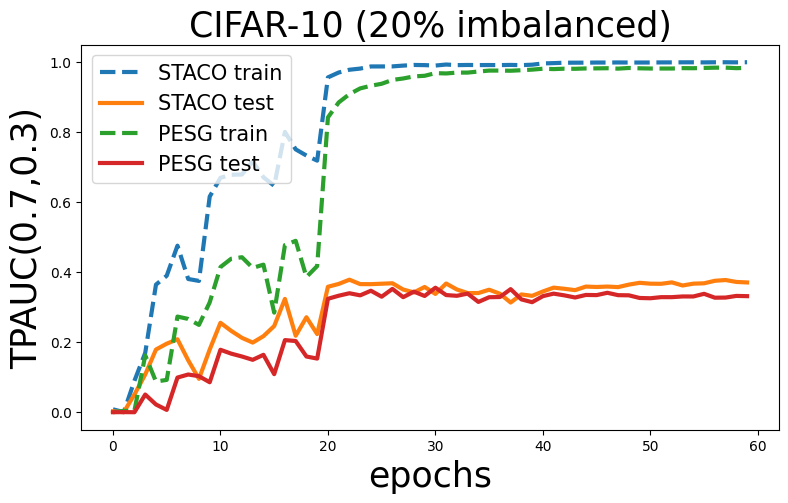

In [8]:
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9,5)
x=np.arange(60)
aucm_tr_tpAUC = [0.0, 0.0036274632780175535, 0.005047971892709222, 0.16224877002854712, 0.08772204107278256, 0.09231572626711304, 0.2732654643710093, 0.26647582593555136, 0.24948327111467297, 0.3138958243403896, 0.41470878408333095, 0.43854233806173326, 0.44279415206018125, 0.41232459713094294, 0.42158369465786594, 0.28455608967939594, 0.47755676075725645, 0.4896781046120168, 0.3863189337375359, 0.41758365936793596, 0.842293465507402, 0.8849664436167597, 0.908744785930645, 0.925100663457797, 0.9326945885667315, 0.9383691079068582, 0.9493701298918441, 0.953469756067609, 0.959401363614275, 0.9611639035102166, 0.9687268876750703, 0.96784177567828, 0.9702642497143897, 0.9702752956047458, 0.9733664551144465, 0.9760006331554156, 0.9760579703978677, 0.9755799377033129, 0.9770459817114208, 0.9787550086264667, 0.9813317160205113, 0.9802740408912104, 0.9814502948096553, 0.9811205278462805, 0.9821393644867049, 0.9823378881296415, 0.9827693626631546, 0.9815768245053843, 0.9835002857701681, 0.9825182242961066, 0.9819347131316462, 0.9819089304938505, 0.9819178330190087, 0.9830069649230193, 0.982775401438961, 0.9835906895346361, 0.9843369096878757, 0.9844427527966737, 0.9829346774859711, 0.9838700118199921]
aucm_te_tpAUC = [0.0, 0.000301777777777778, 0.0, 0.050526666666666664, 0.022042666666666665, 0.006600444444444444, 0.09903022222222221, 0.10774866666666666, 0.1029888888888889, 0.08559822222222221, 0.17839955555555553, 0.16736266666666666, 0.1591968888888889, 0.14970355555555553, 0.16401288888888887, 0.10874133333333333, 0.2060488888888889, 0.20340622222222224, 0.15917866666666666, 0.15321466666666667, 0.3240817777777778, 0.3328191111111111, 0.33990511111111105, 0.33390533333333333, 0.3470675555555556, 0.3300217777777778, 0.35229422222222223, 0.32868844444444445, 0.34444044444444444, 0.33212177777777785, 0.3557311111111111, 0.33471155555555554, 0.332584, 0.3388742222222223, 0.31508044444444444, 0.3285328888888889, 0.32913555555555557, 0.35162800000000005, 0.32234244444444443, 0.31436844444444445, 0.331578888888889, 0.3387742222222222, 0.3338368888888889, 0.3277377777777778, 0.335048, 0.3345755555555555, 0.34122044444444444, 0.3344044444444444, 0.33397066666666664, 0.32639111111111113, 0.3255946666666667, 0.3287395555555556, 0.3287168888888889, 0.33072799999999997, 0.3306648888888889, 0.33826266666666666, 0.3271982222222222, 0.3275493333333333, 0.33227422222222225, 0.33158488888888893]
plt.figure()
plt.plot(x, tr_tpAUC, linestyle='--', label='STACO train', linewidth=3)
plt.plot(x, te_tpAUC, label='STACO test', linewidth=3)
plt.plot(x, aucm_tr_tpAUC, linestyle='--', label='PESG train', linewidth=3)
plt.plot(x, aucm_te_tpAUC, label='PESG test', linewidth=3)
plt.title('CIFAR-10 (20% imbalanced)',fontsize=25)
plt.legend(fontsize=15)
plt.ylabel('TPAUC(0.7,0.3)',fontsize=25)
plt.xlabel('epochs',fontsize=25)